In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install librosa tensorflow scikit-learn seaborn

In [3]:
import os

dataset_path = "/content/drive/MyDrive/NLP_PHASE_2/TESS Toronto emotional speech set data"

print(os.listdir(dataset_path)[:5])

['OAF_happy', 'OAF_Fear', 'OAF_angry', 'OAF_disgust', 'OAF_neutral']


In [4]:
import os

dataset_path = "/content/drive/MyDrive/NLP_PHASE_2/TESS Toronto emotional speech set data"

for root, dirs, files in os.walk(dataset_path):

    for file in files[:20]:

        print(file)

OAF_calm_happy.wav
OAF_bought_happy.wav
OAF_doll_happy.wav
OAF_bite_happy.wav
OAF_date_happy.wav
OAF_came_happy.wav
OAF_bone_happy.wav
OAF_beg_happy.wav
OAF_book_happy.wav
OAF_dog_happy.wav
OAF_bean_happy.wav
OAF_dead_happy.wav
OAF_boat_happy.wav
OAF_ditch_happy.wav
OAF_dab_happy.wav
OAF_chat_happy.wav
OAF_chain_happy.wav
OAF_cause_happy.wav
OAF_fall_happy.wav
OAF_gas_happy.wav
OAF_ditch_fear.wav
OAF_choice_fear.wav
OAF_came_fear.wav
OAF_chat_fear.wav
OAF_chain_fear.wav
OAF_dog_fear.wav
OAF_dime_fear.wav
OAF_bar_fear.wav
OAF_death_fear.wav
OAF_doll_fear.wav
OAF_chief_fear.wav
OAF_cause_fear.wav
OAF_calm_fear.wav
OAF_back_fear.wav
OAF_dead_fear.wav
OAF_bought_fear.wav
OAF_chalk_fear.wav
OAF_dip_fear.wav
OAF_chair_fear.wav
OAF_book_fear.wav
OAF_chat_angry.wav
OAF_fat_angry.wav
OAF_bath_angry.wav
OAF_gap_angry.wav
OAF_date_angry.wav
OAF_cool_angry.wav
OAF_bean_angry.wav
OAF_chalk_angry.wav
OAF_bar_angry.wav
OAF_dog_angry.wav
OAF_dead_angry.wav
OAF_book_angry.wav
OAF_cab_angry.wav
OAF_chai

In [5]:

# IMPORT LIBRARIES

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import Bidirectional
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Flatten

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.utils import to_categorical

In [6]:

# EXTRACT TEXT AND EMOTION LABELS

texts = []
labels = []

print("Loading text data...")

for root, dirs, files in os.walk(dataset_path):

    for file in files:

        if file.endswith(".wav"):

            # REMOVE FILE EXTENSION

            filename = file.replace(".wav", "")



            parts = filename.split("_")

            word = parts[1].lower().strip()

            emotion = parts[-1].lower().strip()

            emotion = emotion.split(" ")[0]


            # STORE DATA


            texts.append(word)
            labels.append(emotion)

print("Dataset Loaded Successfully!")

print("\nSample Texts:")
print(texts[:10])

print("\nEmotion Classes:")
print(sorted(set(labels)))

print("\nTotal Text Samples:")
print(len(texts))

Loading text data...
Dataset Loaded Successfully!

Sample Texts:
['calm', 'bought', 'doll', 'bite', 'date', 'came', 'bone', 'beg', 'book', 'dog']

Emotion Classes:
['angry', 'disgust', 'fear', 'happy', 'neutral', 'ps', 'sad']

Total Text Samples:
2803


In [7]:

# TOKENIZATION

tokenizer = Tokenizer()

tokenizer.fit_on_texts(texts)

sequences = tokenizer.texts_to_sequences(texts)

# padding
X = pad_sequences(
    sequences,
    padding='post'
)

print("Tokenized Text Shape:", X.shape)

Tokenized Text Shape: (2803, 1)


In [8]:

# LABEL ENCODING


encoder = LabelEncoder()

y_encoded = encoder.fit_transform(labels)

y = to_categorical(y_encoded)

print("Emotion Classes:")
print(encoder.classes_)

Emotion Classes:
['angry' 'disgust' 'fear' 'happy' 'neutral' 'ps' 'sad']


In [9]:

# BUILD TEXT MODEL


from tensorflow.keras.layers import Flatten

vocab_size = len(tokenizer.word_index) + 1

model = Sequential()

model.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=32,
        input_length=X.shape[1]
    )
)

model.add(Flatten())

model.add(Dense(64, activation='relu'))

model.add(Dropout(0.3))

model.add(Dense(y.shape[1], activation='softmax'))

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.build(input_shape=(None, X.shape[1]))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 1, 32)          │         6,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,999 (35.15 KB)

 Trainable params: 8,999 (35.15 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:

# TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])

Training Samples: 2242
Testing Samples: 561


In [11]:

# TRAIN MODEL

history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - accuracy: 0.1008 - loss: 1.9499 - val_accuracy: 0.0998 - val_loss: 1.9518
Epoch 2/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1289 - loss: 1.9473 - val_accuracy: 0.0517 - val_loss: 1.9565
Epoch 3/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1338 - loss: 1.9461 - val_accuracy: 0.0339 - val_loss: 1.9615
Epoch 4/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1414 - loss: 1.9450 - val_accuracy: 0.0196 - val_loss: 1.9664
Epoch 5/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1450 - loss: 1.9437 - val_accuracy: 0.0125 - val_loss: 1.9734
Epoch 6/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1445 - loss: 1.9433 - val_accuracy: 0.0125 - val_loss: 1.9818
Epoch 7/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1530 - loss: 1.9411 - val_accuracy: 0.0125 - val_loss: 1.9915
Epoch 8/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1454 - loss: 1.9398 - val_accuracy: 0.0036 - val_loss

In [12]:

# MODEL EVALUATION

loss, accuracy = model.evaluate(X_test, y_test)

print("\nText Model Accuracy:", accuracy)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0018 - loss: 2.2871

Text Model Accuracy: 0.001782531151548028


18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


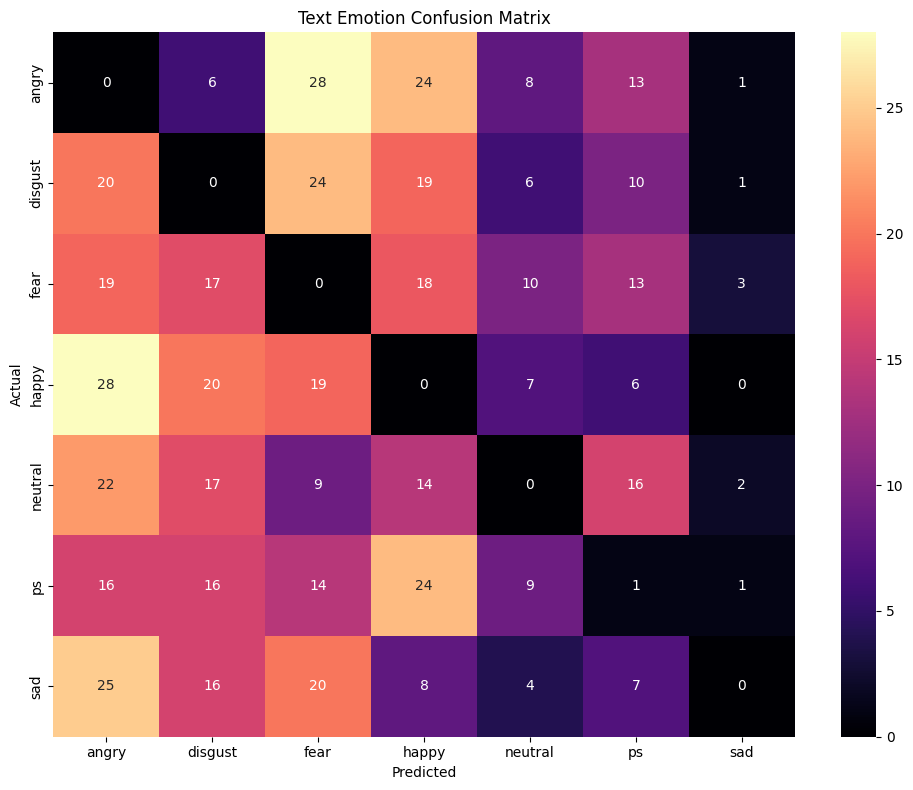

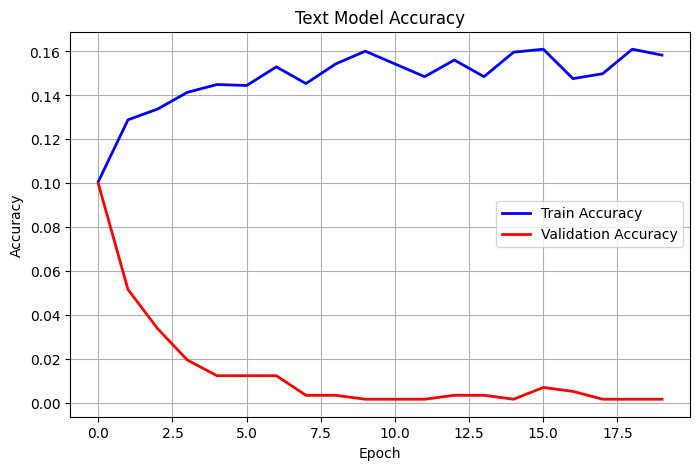

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
              precision    recall  f1-score   support

       angry       0.00      0.00      0.00        80
     disgust       0.00      0.00      0.00        80
        fear       0.00      0.00      0.00        80
       happy       0.00      0.00      0.00        80
     neutral       0.00      0.00      0.00        80
          ps       0.02      0.01      0.01        81
         sad       0.00      0.00      0.00        80

    accuracy                           0.00       561
   macro avg       0.00      0.00      0.00       561
weighted avg       0.00      0.00      0.00       561



In [14]:

# CONFUSION MATRIX

y_pred = model.predict(X_test)

y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='magma',
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Text Emotion Confusion Matrix")

plt.tight_layout()

plt.show()

# ACCURACY PLOT

plt.figure(figsize=(8,5))

plt.plot(
    history.history['accuracy'],
    color='blue',
    linewidth=2,
    label='Train Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    color='red',
    linewidth=2,
    label='Validation Accuracy'
)

plt.title("Text Model Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.show()


# CLASSIFICATION REPORT


y_pred = model.predict(X_test)

y_pred_classes = np.argmax(y_pred, axis=1)

y_true = np.argmax(y_test, axis=1)

print(
    classification_report(
        y_true,
        y_pred_classes,
        target_names=encoder.classes_,
        zero_division=0
    )
)



18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step


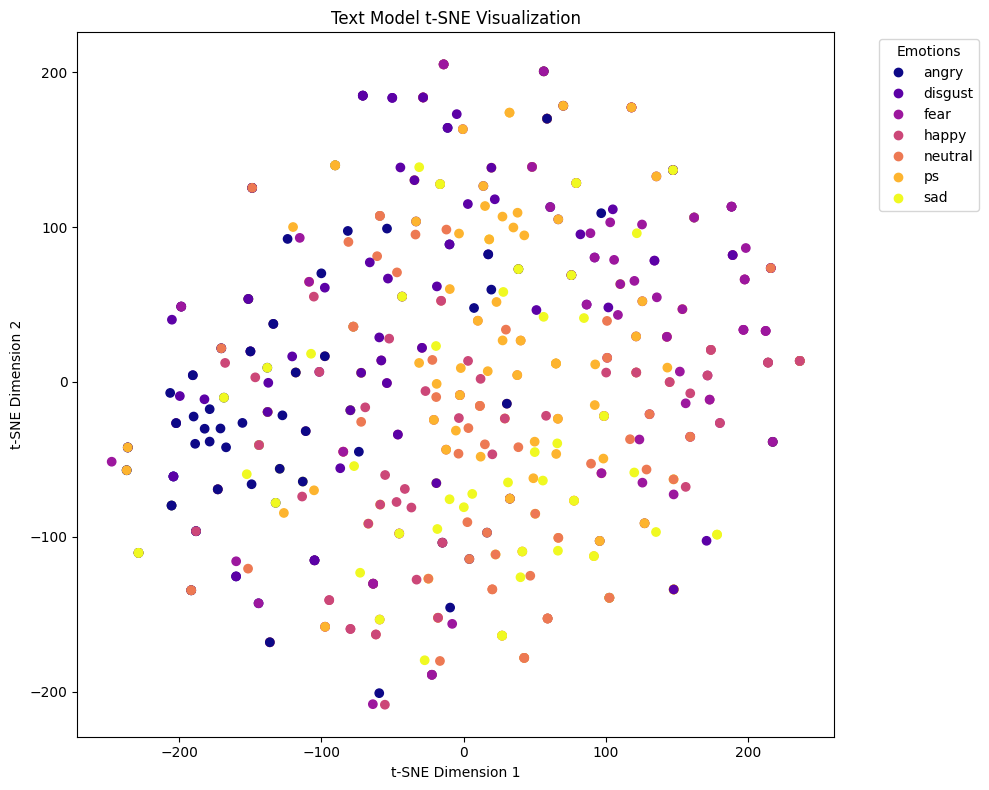

In [16]:

# TEXT MODEL t-SNE VISUALIZATION


from sklearn.manifold import TSNE
from tensorflow.keras.models import Model

feature_extractor = Model(
    inputs=model.inputs,
    outputs=model.layers[-2].output
)

text_features = feature_extractor.predict(X_test)

tsne = TSNE(
    n_components=2,
    random_state=42
)

tsne_result = tsne.fit_transform(text_features)

y_true = np.argmax(y_test, axis=1)

# PLOT

plt.figure(figsize=(10,8))

scatter = plt.scatter(
    tsne_result[:,0],
    tsne_result[:,1],
    c=y_true,
    cmap='plasma'
)

# LEGEND

handles, _ = scatter.legend_elements()

plt.legend(
    handles,
    encoder.classes_,
    title="Emotions",
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.title("Text Model t-SNE Visualization")

plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")

plt.tight_layout()

plt.show()

In [17]:

# SAVE MODEL


model.save("/content/drive/MyDrive/NLP_PHASE_2/text_model.keras")

print("Text model saved successfully.")

Text model saved successfully.
